In [290]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [291]:
df = pd.read_excel('c:\\Users\\U440845\\Documents\\GitHub\\Miles_Forecasting\\dataset\\forecast_data.xlsx', na_values='None')

In [292]:
df.head()

,year,week,flown miles,rpms,Premier Redeemed,accrued miles,Booked Miles,Card Memb Redeemed
0,2019,1,429517650,4295194857,216525500,2832519813,429517650,553797300
1,2019,2,865798510,3955266034,386611750,6390068484,865798510,1078995900
2,2019,3,1300129701,3705857919,595980450,6342604373,1300129701,1624655603
3,2019,4,1347616500,3659307798,598176500,6638428411,1347616500,1665879750
4,2019,5,1586048001,3547960834,685615000,729343040,1586048001,1941830502


In [293]:
# ISO week -> Monday of that week
df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-' + df['week'].astype(str) + '-1',
    format='%G-%V-%u'
)

In [294]:
print(df[['year','week','date']].head(10))
print(df[['year','week','date']].tail(10))

   year  week       date
0  2019     1 2018-12-31
1  2019     2 2019-01-07
2  2019     3 2019-01-14
3  2019     4 2019-01-21
4  2019     5 2019-01-28
5  2019     6 2019-02-04
6  2019     7 2019-02-11
7  2019     8 2019-02-18
8  2019     9 2019-02-25
9  2019    10 2019-03-04
     year  week       date
382  2026    18 2026-04-27
383  2026    19 2026-05-04
384  2026    20 2026-05-11
385  2026    21 2026-05-18
386  2026    22 2026-05-25
387  2026    23 2026-06-01
388  2026    24 2026-06-08
389  2026    25 2026-06-15
390  2026    26 2026-06-22
391  2026    27 2026-06-29


In [295]:
import holidays

# US holidays relevant to travel — pull for full range of years in your data
us_holidays = holidays.US(years=range(df['year'].min(), df['year'].max() + 2))

# Filter to travel-relevant holidays only (skip minor ones like Columbus Day if not relevant)
travel_holidays = {
    date: name for date, name in us_holidays.items()
    if any(h in name for h in [
        'New Year', 'Memorial Day', 'Independence Day',
        'Labor Day', 'Thanksgiving', 'Christmas'
    ])
}

holiday_dates = pd.to_datetime(sorted(travel_holidays.keys()))

def nearest_holiday_info(d):
    diffs = (holiday_dates - d).days
    idx = abs(diffs).argmin()
    nearest_date = holiday_dates[idx]
    signed_days = diffs[idx]  # negative = holiday already passed, positive = upcoming
    name = travel_holidays[nearest_date.date()]
    return signed_days, name

results = df['date'].apply(nearest_holiday_info)
df['days_to_nearest_holiday'] = results.apply(lambda x: x[0])
df['nearest_holiday_name'] = results.apply(lambda x: x[1])

# Binary flag: within ±3 days of a travel holiday (tune this window based on your data)
df['is_holiday_week'] = (df['days_to_nearest_holiday'].abs() <= 3).astype(int)

# Pre/post holiday flags — travel often spikes the week before AND after
df['is_pre_holiday'] = ((df['days_to_nearest_holiday'] > 0) & (df['days_to_nearest_holiday'] <= 7)).astype(int)
df['is_post_holiday'] = ((df['days_to_nearest_holiday'] < 0) & (df['days_to_nearest_holiday'] >= -7)).astype(int)

In [296]:
holiday_dummies = pd.get_dummies(df['nearest_holiday_name'], prefix='holiday')
df = pd.concat([df, holiday_dummies], axis=1)

In [297]:
df["flown miles lag_52"]  = df["flown miles"].shift(52)
df["flown miles lag_104"] = df["flown miles"].shift(104)
df["flown miles rolling mean 3"] = df["flown miles"].shift(1).rolling(window=3).mean()

In [298]:
#adding lags for booked miles
df["booked_miles_lag_1"] = df["Booked Miles"].shift(1)
df["booked_miles_lag_3"] = df["Booked Miles"].shift(3)
df["booked_miles_lag_6"] = df["Booked Miles"].shift(6)

In [299]:
df["card_mem_lag_1"] = df["Card Memb Redeemed"].shift(1)

In [300]:
df["rpms_lag_1"] = df["rpms"].shift(1)

In [301]:
#adding lags for booked miles
df["prem_rdm_lag_1"] = df["Premier Redeemed"].shift(1)
df["prem_rdm_lag_3"] = df["Premier Redeemed"].shift(3)
df["prem_rdm_lag_6"] = df["Premier Redeemed"].shift(6)

In [302]:
df["accrued_miles_lag_1"] = df["accrued miles"].shift(1)
df["accrued_miles_lag_3"] = df["accrued miles"].shift(3)
df["accrued_miles_lag_6"] = df["accrued miles"].shift(6)

In [303]:
# 1st harmonic
df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)

# 2nd harmonic — captures twice-a-year cycles (e.g. summer + winter holiday peaks)
df['week_sin_2'] = np.sin(2 * np.pi * 2 * df['week'] / 52)
df['week_cos_2'] = np.cos(2 * np.pi * 2 * df['week'] / 52)

# 3rd harmonic — captures finer sub-annual wiggles (quarterly-ish patterns)
df['week_sin_3'] = np.sin(2 * np.pi * 3 * df['week'] / 52)
df['week_cos_3'] = np.cos(2 * np.pi * 3 * df['week'] / 52)

In [304]:
df["load_factor_proxy"] = df["rpms"].shift(1) / df["flown miles"].shift(1)

In [305]:
df["booking_pressure"] = df["Booked Miles"].shift(1) / df["flown miles"].shift(1)

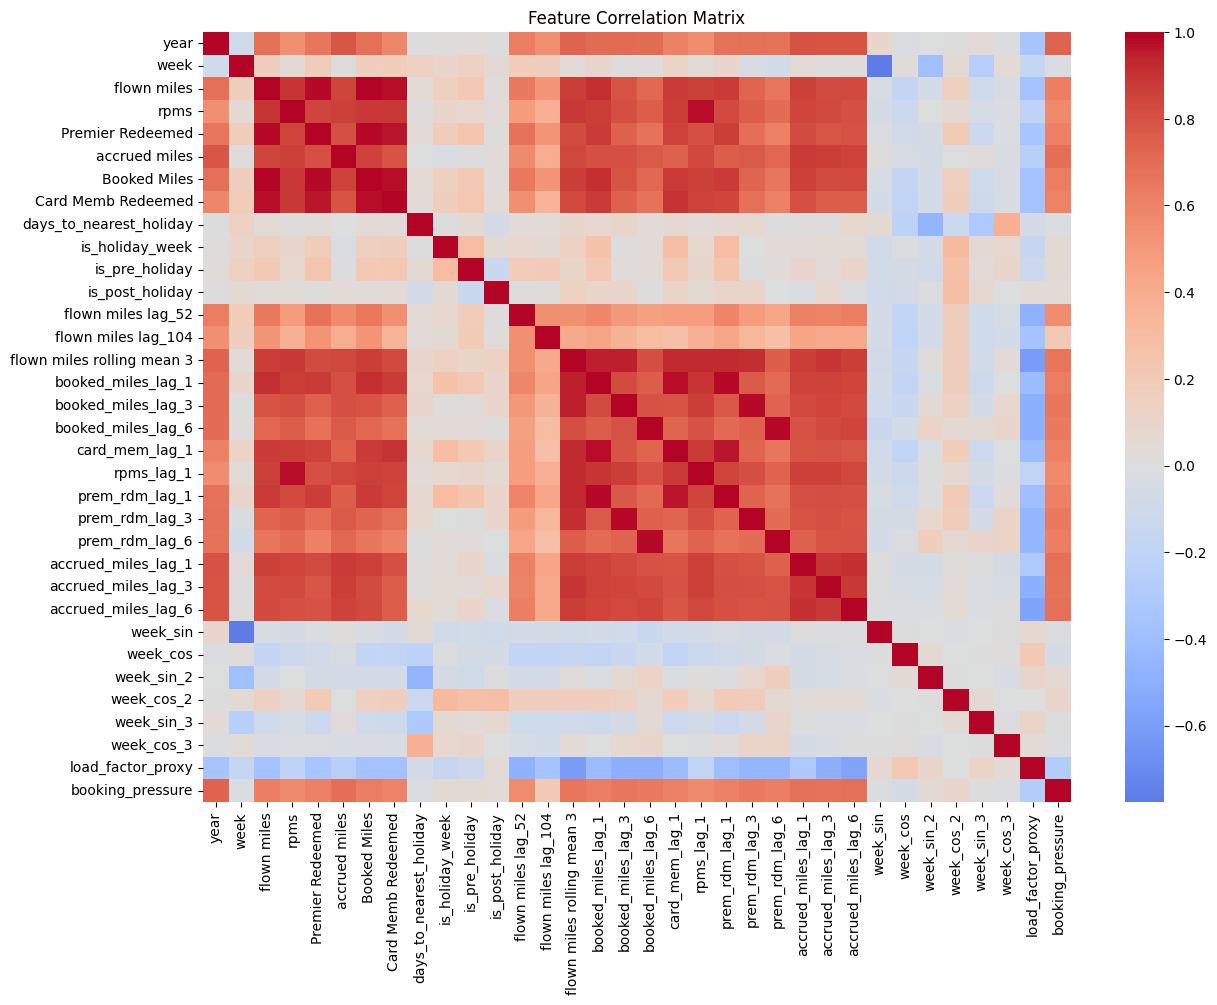

In [306]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(14,10))
sns.heatmap(
    df[numeric_cols].corr(),
    cmap='coolwarm',
    center=0
)
plt.title('Feature Correlation Matrix')
plt.show()

In [307]:
df.corr(numeric_only=True)['flown miles'].sort_values(ascending=False)

flown miles                                                1.000000
Booked Miles                                               0.999993
Premier Redeemed                                           0.986097
Card Memb Redeemed                                         0.976531
booked_miles_lag_1                                         0.906394
rpms                                                       0.889120
card_mem_lag_1                                             0.881713
prem_rdm_lag_1                                             0.876717
flown miles rolling mean 3                                 0.866866
accrued_miles_lag_1                                        0.859154
rpms_lag_1                                                 0.857897
accrued miles                                              0.847271
accrued_miles_lag_6                                        0.826668
accrued_miles_lag_3                                        0.823908
booked_miles_lag_3                              

In [333]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [347]:
from scipy.stats import randint, uniform
from joblib import Parallel, delayed
import time

# ---- 1. Search space ----
param_distributions = {
    'n_estimators': randint(200, 1200),
    'max_depth': randint(2, 6),
    'learning_rate': uniform(0.005, 0.095),   # 0.005 to 0.1
    'subsample': uniform(0.5, 0.4),           # 0.5 to 0.9
    'colsample_bytree': uniform(0.5, 0.4),    # 0.5 to 0.9
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 2),
}

# ---- 2. Scoring function (imports are INSIDE, so parallel workers have them) ----
def walk_forward_score(params, df_model, FEATURES, TARGET, initial_train_size):
    from sklearn.metrics import mean_absolute_percentage_error
    from xgboost import XGBRegressor

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        **params
    )
    predictions = []
    actuals = []
    for i in range(initial_train_size, len(df_model)):
        train, test = walk_forward_split(df_model, i)
        train = train[train['is_covid_period'] == 0]
        X_train, y_train = train[FEATURES], train[TARGET]
        X_test, y_test = test[FEATURES], test[TARGET]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)[0]
        predictions.append(y_pred)
        actuals.append(y_test.values[0])
    mape = mean_absolute_percentage_error(actuals, predictions) * 100
    return mape, predictions, actuals

# ---- 3. Quick timing check on ONE combo first ----
start = time.time()
_ = walk_forward_score(
    {'n_estimators': 800, 'max_depth': 2, 'learning_rate': 0.01,
     'subsample': 0.7, 'colsample_bytree': 0.7},
    df_model, FEATURES, TARGET, initial_train_size
)
elapsed = time.time() - start
import os
print(f"One full walk-forward pass took {elapsed:.1f} seconds")
print(f"Rough estimate for 30 combos with n_jobs=-1: {(elapsed * 30 / max(1, os.cpu_count()-1)):.1f} seconds")

# ---- 4. Sample 30 random param combos ----
n_iter = 30
rng = np.random.RandomState(42)

sampled_params = []
for _ in range(n_iter):
    combo = {k: dist.rvs(random_state=rng) for k, dist in param_distributions.items()}
    combo['max_depth'] = int(combo['max_depth'])
    combo['n_estimators'] = int(combo['n_estimators'])
    combo['min_child_weight'] = int(combo['min_child_weight'])
    sampled_params.append(combo)

# ---- 5. Run the search in parallel ----
results_list = Parallel(n_jobs=-1, verbose=10)(
    delayed(walk_forward_score)(params, df_model, FEATURES, TARGET, initial_train_size)
    for params in sampled_params
)

scores = [r[0] for r in results_list]
best_idx = np.argmin(scores)
best_params = sampled_params[best_idx]
best_mape = scores[best_idx]

print(f"\nBest weekly MAPE: {best_mape:.2f}%")
print(f"Best params: {best_params}")

One full walk-forward pass took 168.4 seconds
Rough estimate for 30 combos with n_jobs=-1: 388.7 seconds


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  30 | elapsed:  4.1min remaining: 13.3min
[Parallel(n_jobs=-1)]: Done  11 out of  30 | elapsed:  5.9min remaining: 10.2min
[Parallel(n_jobs=-1)]: Done  15 out of  30 | elapsed:  7.1min remaining:  7.1min
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed:  9.0min remaining:  5.2min
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:  9.5min remaining:  2.9min
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed: 11.5min remaining:  1.3min



Best weekly MAPE: 6.71%
Best params: {'n_estimators': 846, 'max_depth': 2, 'learning_rate': np.float64(0.04779742893710658), 'subsample': np.float64(0.5053059844639466), 'colsample_bytree': np.float64(0.8768807022739411), 'min_child_weight': 2, 'gamma': np.float64(0.19270825126995805), 'reg_alpha': np.float64(0.015966252220214194), 'reg_lambda': np.float64(0.961787651244298)}


[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed: 12.4min finished


In [337]:
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances)

flown miles lag_52            0.232847
booked_miles_lag_1            0.229330
prem_rdm_lag_1                0.158568
card_mem_lag_1                0.049091
flown miles rolling mean 3    0.047987
flown miles lag_104           0.038899
week_cos_2                    0.036094
is_pre_holiday                0.025966
week_cos                      0.019697
week                          0.016907
accrued_miles_lag_1           0.015194
accrued_miles_lag_6           0.013985
load_factor_proxy             0.013064
is_post_holiday               0.012105
rpms_lag_1                    0.011442
prem_rdm_lag_3                0.008554
accrued_miles_lag_3           0.008157
booked_miles_lag_3            0.007125
week_sin_3                    0.007103
booking_pressure              0.006602
week_sin_2                    0.005971
days_to_nearest_holiday       0.005418
is_holiday_week               0.005247
year                          0.005111
week_sin                      0.005054
week_cos_3               

In [338]:
TARGET = "flown miles"
FEATURES = [
    "week",
    "year",
    # "Premier Redeemed",
    "accrued_miles_lag_1",
    "accrued_miles_lag_3",
    "accrued_miles_lag_6",
    'rpms_lag_1',
    # 'Booked Miles',
    # 'gross passenger revenue',
    "flown miles lag_52",
    "flown miles lag_104",
    "booked_miles_lag_1",
    "booked_miles_lag_3",
    "booked_miles_lag_6",
    "prem_rdm_lag_1",
    "prem_rdm_lag_3",
    "prem_rdm_lag_6",
    "flown miles rolling mean 3",
    "week_sin",
    "week_cos",
    "week_sin_2",
    "week_cos_2",
    "week_sin_3",
    "week_cos_3",
    # "accrued:redeemed",
    "booking_pressure",
    "load_factor_proxy",
    "card_mem_lag_1",
    "days_to_nearest_holiday",
    "is_holiday_week",
    "is_pre_holiday",
    "is_post_holiday",
    "is_covid_period"
]

In [339]:
def walk_forward_split(df, train_size):
    train = df.iloc[:train_size]
    test = df.iloc[train_size:train_size + 1]
    return train, test

In [340]:
covid_start = pd.Timestamp('2020-03-01')
covid_end = pd.Timestamp('2021-06-30')

df['is_covid_period'] = ((df['date'] >= covid_start) & (df['date'] <= covid_end)).astype(int)

In [341]:
df_model = df[FEATURES + [TARGET]].dropna().reset_index(drop=True)

In [342]:
data_cutoff = pd.Timestamp('2026-06-30')

# a full week's data is only trustworthy if the week's end date has passed
df['week_end_date'] = df['date'] + pd.Timedelta(days=6)
df_model = df[df['week_end_date'] <= data_cutoff].copy()

Top 10 worst weeks (by ISO week number, averaged across years):
week
48    24.724823
46    23.237388
7     16.974069
1     16.401098
3     15.695458
51    15.287159
49    13.739306
15    13.644774
4     12.872887
43    12.309482
Name: abs_pct_error, dtype: float64

MAPE by year:
year
2022    10.736369
2024     8.089029
2023     8.038887
2026     7.903146
2025     5.859655
Name: abs_pct_error, dtype: float64

Mean signed error: -112,721,379
(positive = over-forecasting on average, negative = under-forecasting)

MAPE: holiday vs non-holiday weeks
is_holiday_week
0    8.114796
1    8.381388
Name: abs_pct_error, dtype: float64


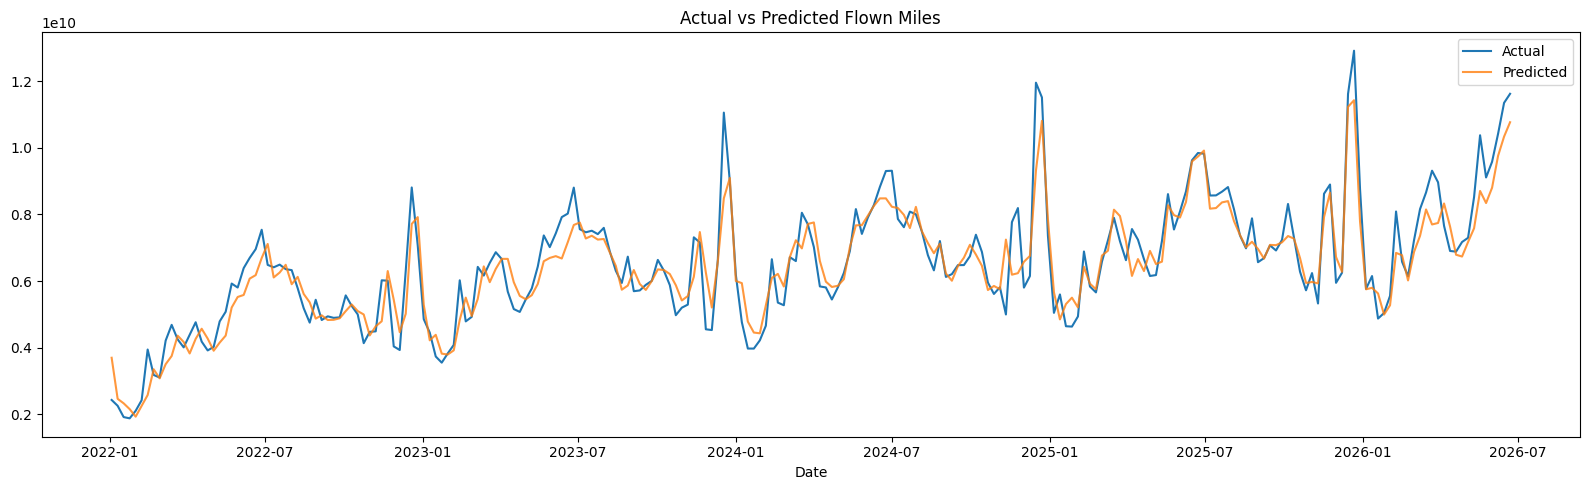

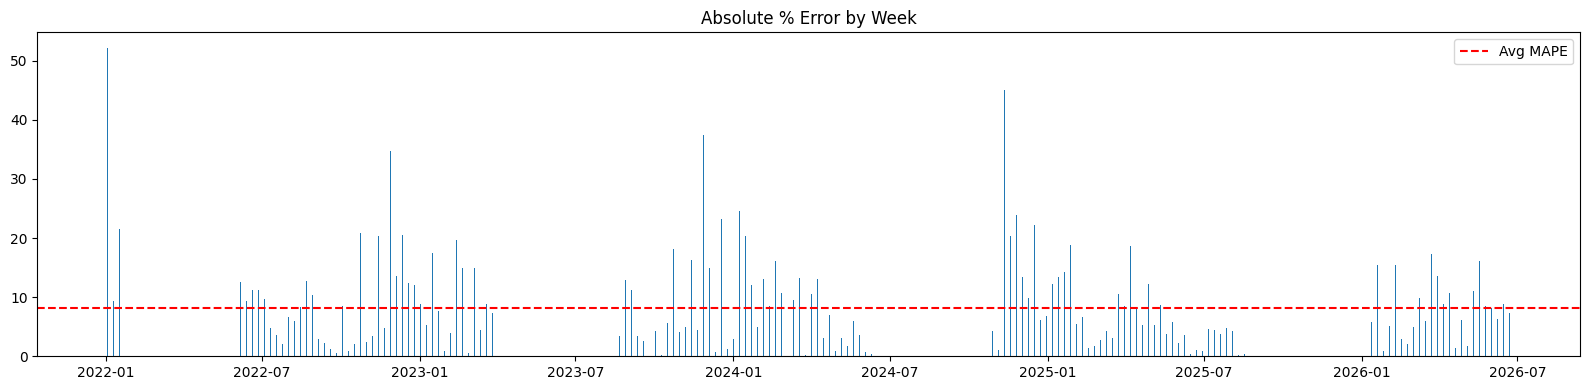

In [343]:
results = df_model.iloc[initial_train_size:].copy()
results['date'] = df.loc[results.index, 'date']
results['predicted'] = predictions
results['actual'] = actuals
results['abs_pct_error'] = np.abs((results['actual'] - results['predicted']) / results['actual']) * 100
results['error'] = results['predicted'] - results['actual']  # signed: positive = over-forecast

# 1. Error by ISO week-of-year — averaged across all years in test set
weekly_error = results.groupby('week')['abs_pct_error'].mean().sort_values(ascending=False)
print("Top 10 worst weeks (by ISO week number, averaged across years):")
print(weekly_error.head(10))

# 2. Error by year — is the model getting worse over time, or consistent?
yearly_error = results.groupby('year')['abs_pct_error'].mean().sort_values(ascending=False)
print("\nMAPE by year:")
print(yearly_error)

# 3. Bias check — is the model systematically over or under forecasting?
print(f"\nMean signed error: {results['error'].mean():,.0f}")
print(f"(positive = over-forecasting on average, negative = under-forecasting)")

# 4. Are holiday weeks specifically worse than non-holiday weeks?
if 'is_holiday_week' in results.columns:
    print("\nMAPE: holiday vs non-holiday weeks")
    print(results.groupby('is_holiday_week')['abs_pct_error'].mean())

# 5. Plot actual vs predicted over time — visual check for systematic misses
plt.figure(figsize=(16, 5))
plt.plot(results['date'], results['actual'], label='Actual', linewidth=1.5)
plt.plot(results['date'], results['predicted'], label='Predicted', linewidth=1.5, alpha=0.8)
plt.legend()
plt.title('Actual vs Predicted Flown Miles')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

# 6. Plot error over time — spot clusters of bad weeks
plt.figure(figsize=(16, 4))
plt.bar(results['date'], results['abs_pct_error'])
plt.axhline(results['abs_pct_error'].mean(), color='red', linestyle='--', label='Avg MAPE')
plt.title('Absolute % Error by Week')
plt.legend()
plt.tight_layout()
plt.show()

In [344]:
df[(df['year']==2026) & (df['week']==27)][['year','week','date']]

,year,week,date
391,2026,27,2026-06-29


In [348]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=846,
    max_depth=2,
    learning_rate=np.float64(0.04779742893710658),
    subsample=np.float64(0.5053059844639466),
    colsample_bytree=np.float64(0.8768807022739411),
    min_child_weight=2,
    gamma=np.float64(0.19270825126995805),
    reg_alpha=np.float64(0.015966252220214194),
    reg_lambda=np.float64(0.961787651244298)
)

In [352]:
predictions = []
actuals = []
test_start_date = pd.Timestamp('2022-01-01')

initial_train_size = df_model[df_model['date'] < test_start_date].shape[0]
print(f"Testing will start from row {initial_train_size}, date {df_model.iloc[initial_train_size]['date']}")

# for i in range(initial_train_size, len(df_model)):
#     train, test = walk_forward_split(df_model, i)
#     X_train = train[FEATURES]
#     y_train = train[TARGET]
#     X_test = test[FEATURES]
#     y_test = test[TARGET]
#     xgb_model.fit(X_train, y_train)
#     y_pred = xgb_model.predict(X_test)[0]
#     predictions.append(y_pred)
#     actuals.append(y_test.values[0])

for i in range(initial_train_size, len(df_model)):
    train, test = walk_forward_split(df_model, i)
    train = train[train['is_covid_period'] == 0]
    X_train = train[FEATURES]
    y_train = train[TARGET]
    X_test = test[FEATURES]
    y_test = test[TARGET]
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)[0]
    predictions.append(y_pred)
    actuals.append(y_test.values[0])

Testing will start from row 157, date 2022-01-03 00:00:00


In [353]:
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
print(f"MAE:  {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")

MAE:  420,387,354
RMSE: 567,264,474


In [355]:
actuals_arr = np.array(actuals)
preds_arr = np.array(predictions)
mape = np.mean(np.abs((actuals_arr - preds_arr) / actuals_arr)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 6.86%


In [356]:
results = df_model.iloc[initial_train_size:].copy()
results['predicted'] = predictions
results['actual'] = actuals
results['date'] = df_model.iloc[initial_train_size:]['date']

In [357]:
print(results['date'].min(), results['date'].max())
print(results['year'].value_counts().sort_index())

2022-01-03 00:00:00 2026-06-22 00:00:00
year
2022    52
2023    52
2024    52
2025    52
2026    26
Name: count, dtype: int64


In [358]:
results['month'] = results['date'].dt.to_period('M')

monthly = results.groupby('month').agg(
    actual_sum=('actual', 'sum'),
    predicted_sum=('predicted', 'sum'),
    n_weeks=('actual', 'count')
).reset_index()

monthly['is_partial_month'] = monthly['n_weeks'] < 4

monthly['abs_pct_error'] = np.abs(
    (monthly['actual_sum'] - monthly['predicted_sum']) / monthly['actual_sum']
) * 100

print(monthly)

monthly_mape = monthly['abs_pct_error'].mean()
print(f"\nMonthly rollup MAPE (all months): {monthly_mape:.2f}%")

monthly_clean = monthly[~monthly['is_partial_month']]
monthly_mape_clean = monthly_clean['abs_pct_error'].mean()
print(f"Monthly rollup MAPE (excluding partial months): {monthly_mape_clean:.2f}%")

      month   actual_sum  predicted_sum  n_weeks  is_partial_month  \
0   2022-01  10579036974   1.215513e+10        5             False   
1   2022-02  12649987312   1.113281e+10        4             False   
2   2022-03  17155797589   1.688078e+10        4             False   
3   2022-04  17247179789   1.646526e+10        4             False   
4   2022-05  25621778725   2.406312e+10        5             False   
5   2022-06  27586643466   2.505542e+10        4             False   
6   2022-07  25752543049   2.600059e+10        4             False   
7   2022-08  27487924466   2.934742e+10        5             False   
8   2022-09  19577929753   2.009141e+10        4             False   
9   2022-10  24431932633   2.534137e+10        5             False   
10  2022-11  20562434125   2.097399e+10        4             False   
11  2022-12  26118690105   2.607883e+10        4             False   
12  2023-01  20421706026   2.070019e+10        5             False   
13  2023-02  1982100

In [359]:
monthly['signed_pct_error'] = (monthly['predicted_sum'] - monthly['actual_sum']) / monthly['actual_sum'] * 100
print(f"Mean signed % error: {monthly['signed_pct_error'].mean():.2f}%")
print(f"% of months over-forecasted: {(monthly['signed_pct_error'] > 0).mean() * 100:.1f}%")

Mean signed % error: -0.76%
% of months over-forecasted: 48.1%


In [362]:
from sklearn.metrics import mean_absolute_percentage_error

last_6mo_cutoff = pd.Timestamp('2026-01-01')
recent_mask = results['date'] >= last_6mo_cutoff

recent_mape = mean_absolute_percentage_error(
    results.loc[recent_mask, 'actual'],
    results.loc[recent_mask, 'predicted']
) * 100
print(f"MAPE on Jan 2026 - June 2026 only: {recent_mape:.2f}%")

MAPE on Jan 2026 - June 2026 only: 6.74%


final forecast

In [363]:
final_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=846,
    max_depth=2,
    learning_rate=np.float64(0.04779742893710658),
    subsample=np.float64(0.5053059844639466),
    colsample_bytree=np.float64(0.8768807022739411),
    min_child_weight=2,
    gamma=np.float64(0.19270825126995805),
    reg_alpha=np.float64(0.015966252220214194),
    reg_lambda=np.float64(0.961787651244298)
)

train_final = df_model[df_model['is_covid_period'] == 0]
final_model.fit(train_final[FEATURES], train_final[TARGET])

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,np.float64(0.8768807022739411)
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = 

In [364]:
def get_seasonal_naive(df_full, col, target_date):
    """Get value from the same week, 52 weeks prior."""
    prior_date = target_date - pd.Timedelta(weeks=52)
    match = df_full[df_full['date'] == prior_date]
    if len(match) == 0:
        # fallback: nearest available date
        idx = (df_full['date'] - prior_date).abs().idxmin()
        return df_full.loc[idx, col]
    return match[col].values[0]

In [365]:
import holidays as holidays_lib

def get_holiday_features(date):
    us_holidays = holidays_lib.US(years=[date.year - 1, date.year, date.year + 1])
    travel_holidays = {
        d: name for d, name in us_holidays.items()
        if any(h in name for h in ['New Year', 'Memorial Day', 'Independence Day',
                                     'Labor Day', 'Thanksgiving', 'Christmas', 'Juneteenth'])
    }
    holiday_dates = pd.to_datetime(sorted(travel_holidays.keys()))
    diffs = (holiday_dates - date).days
    idx = abs(diffs).argmin()
    nearest_date = holiday_dates[idx]
    signed_days = diffs[idx]
    name = travel_holidays[nearest_date.date()]
    return signed_days, name

In [366]:
import numpy as np
import pandas as pd

n_weeks_forecast = 52
last_known_date = df['date'].max()

# working copy that grows with each predicted week
df_extended = df.copy()

forecast_rows = []

for step in range(1, n_weeks_forecast + 1):
    target_date = last_known_date + pd.Timedelta(weeks=step)
    iso_year, iso_week, _ = target_date.isocalendar()

    # --- approximate raw helper inputs via seasonal naive ---
    row = {
        'date': target_date,
        'year': iso_year,
        'week': iso_week,
        'rpms': get_seasonal_naive(df_extended, 'rpms', target_date),
        'Premier Redeemed': get_seasonal_naive(df_extended, 'Premier Redeemed', target_date),
        'accrued miles': get_seasonal_naive(df_extended, 'accrued miles', target_date),
        'Booked Miles': get_seasonal_naive(df_extended, 'Booked Miles', target_date),
        'Card Memb Redeemed': get_seasonal_naive(df_extended, 'Card Memb Redeemed', target_date),
    }

    # --- lag features (pull from df_extended, which includes prior PREDICTED weeks) ---
    def get_lagged(col, lag_weeks):
        lag_date = target_date - pd.Timedelta(weeks=lag_weeks)
        match = df_extended[df_extended['date'] == lag_date]
        return match[col].values[0] if len(match) else np.nan

    row['prem_rdm_lag_1'] = get_lagged('Premier Redeemed', 1)
    row['prem_rdm_lag_3'] = get_lagged('Premier Redeemed', 3)
    row['prem_rdm_lag_6'] = get_lagged('Premier Redeemed', 6)
    row['booked_miles_lag_1'] = get_lagged('Booked Miles', 1)
    row['booked_miles_lag_3'] = get_lagged('Booked Miles', 3)
    row['booked_miles_lag_6'] = get_lagged('Booked Miles', 6)
    row['card_mem_lag_1'] = get_lagged('Card Memb Redeemed', 1)
    row['rpms_lag_1'] = get_lagged('rpms', 1)
    row['accrued_miles_lag_1'] = get_lagged('accrued miles', 1)
    row['accrued_miles_lag_3'] = get_lagged('accrued miles', 3)
    row['accrued_miles_lag_6'] = get_lagged('accrued miles', 6)

    row['flown miles lag_3'] = get_lagged('flown miles', 3)
    row['flown miles lag_12'] = get_lagged('flown miles', 12)
    row['flown miles lag_52'] = get_lagged('flown miles', 52)
    row['flown miles lag_104'] = get_lagged('flown miles', 104)

    # rolling mean 3 (shifted — uses last 3 known/predicted weeks, not current)
    last_3 = [get_lagged('flown miles', k) for k in [1, 2, 3]]
    row['flown miles rolling mean 3'] = np.nanmean(last_3)

    # ratio features (using lagged inputs so no leakage)
    fm_lag1 = get_lagged('flown miles', 1)
    row['load_factor_proxy'] = row['rpms_lag_1'] / fm_lag1 if fm_lag1 else np.nan
    row['booking_pressure'] = row['booked_miles_lag_1'] / fm_lag1 if fm_lag1 else np.nan

    # Fourier harmonics
    for k in [1, 2, 3]:
        row[f'week_sin' + ('' if k == 1 else f'_{k}')] = np.sin(2 * np.pi * k * iso_week / 52)
        row[f'week_cos' + ('' if k == 1 else f'_{k}')] = np.cos(2 * np.pi * k * iso_week / 52)

    # holiday features
    signed_days, holiday_name = get_holiday_features(target_date)
    row['days_to_nearest_holiday'] = signed_days
    row['is_holiday_week'] = int(abs(signed_days) <= 3)
    row['is_pre_holiday'] = int(0 < signed_days <= 7)
    row['is_post_holiday'] = int(-7 <= signed_days < 0)
    for h_col in [c for c in FEATURES if c.startswith('holiday_')]:
        row[h_col] = 0
    holiday_dummy_col = f'holiday_{holiday_name}'
    if holiday_dummy_col in FEATURES:
        row[holiday_dummy_col] = 1

    row['is_covid_period'] = 0  # future weeks are never COVID period

    # --- predict ---
    X_pred = pd.DataFrame([row])[FEATURES]
    pred_flown_miles = final_model.predict(X_pred)[0]
    row['flown miles'] = pred_flown_miles
    row['predicted'] = pred_flown_miles  # flag it as a forecast, not actual

    forecast_rows.append(row)
    df_extended = pd.concat([df_extended, pd.DataFrame([row])], ignore_index=True)

forecast_df = pd.DataFrame(forecast_rows)
print(forecast_df[['date', 'year', 'week', 'flown miles']])

         date  year  week   flown miles
0  2026-07-06  2026    28  7.499912e+09
1  2026-07-13  2026    29  9.307862e+09
2  2026-07-20  2026    30  1.013654e+10
3  2026-07-27  2026    31  1.022959e+10
4  2026-08-03  2026    32  9.323065e+09
5  2026-08-10  2026    33  7.626684e+09
6  2026-08-17  2026    34  7.549661e+09
7  2026-08-24  2026    35  8.225909e+09
8  2026-08-31  2026    36  7.328914e+09
9  2026-09-07  2026    37  7.144742e+09
10 2026-09-14  2026    38  7.499316e+09
11 2026-09-21  2026    39  7.457569e+09
12 2026-09-28  2026    40  7.651472e+09
13 2026-10-05  2026    41  9.020704e+09
14 2026-10-12  2026    42  7.851347e+09
15 2026-10-19  2026    43  6.458669e+09
16 2026-10-26  2026    44  5.941851e+09
17 2026-11-02  2026    45  6.500529e+09
18 2026-11-09  2026    46  5.638853e+09
19 2026-11-16  2026    47  9.468916e+09
20 2026-11-23  2026    48  1.080041e+10
21 2026-11-30  2026    49  6.546922e+09
22 2026-12-07  2026    50  6.336229e+09
23 2026-12-14  2026    51  1.199076e+10


In [367]:
forecast_df['month'] = forecast_df['date'].dt.to_period('M')
monthly_forecast = forecast_df.groupby('month').agg(
    forecasted_flown_miles=('flown miles', 'sum'),
    n_weeks=('flown miles', 'count')
).reset_index()

print(monthly_forecast)

      month  forecasted_flown_miles  n_weeks
0   2026-07            3.717390e+10        4
1   2026-08            4.005424e+10        5
2   2026-09            2.975310e+10        4
3   2026-10            2.927257e+10        4
4   2026-11            3.895563e+10        5
5   2026-12            4.303446e+10        4
6   2027-01            2.313801e+10        4
7   2027-02            2.699191e+10        4
8   2027-03            4.552776e+10        5
9   2027-04            3.105359e+10        4
10  2027-05            4.656370e+10        5
11  2027-06            4.038580e+10        4
